# Đồ án nhận diện cảm xúc khuôn mặt bằng CNN, ResNet18 và EfficientNet-B0

Trong đồ án này, em lần lượt thử nghiệm ba mô hình trên các tập `Train`, `Val` và `Test`:

1. Em xây dựng và huấn luyện mô hình CNN cơ sở từ đầu.
2. Em sử dụng ResNet18 đã được huấn luyện trước và fine-tune trên bộ dữ liệu của đồ án.
3. Em fine-tune thêm EfficientNet-B0 (`enet_b0_8_best_vgaf`) cho 8 lớp cảm xúc.

Mỗi cấu hình được em huấn luyện từ 20 epoch trở lên. Sau mỗi lần chạy, notebook sẽ lưu
các biểu đồ, bảng chỉ số Accuracy/Loss/F1 và ma trận nhầm lẫn để em dùng trong báo cáo.
Em chọn checkpoint tốt nhất dựa trên độ chính xác của tập xác thực, sau đó mới đánh giá
kết quả trên tập kiểm tra.

In [1]:
from __future__ import annotations

import copy
import csv
import hashlib
import json
import os
import random
import shutil
import subprocess
import sys
import time
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
from PIL import Image
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("Scikit-learn:", sklearn.__version__)

PyTorch: 2.12.0+cu126
Torchvision: 0.27.0+cu126
Scikit-learn: 1.7.2


## 1. Thiết lập các tham số ban đầu

In [ ]:
SEED = 42
MIN_EPOCHS = 20                 # Em đặt tối thiểu 20 epoch cho mỗi lần huấn luyện.
IMAGE_SIZE = 224
BATCH_SIZE = 80
NUM_WORKERS = 0                 # Em dùng 0 để DataLoader chạy ổn định trên Windows.
CNN_EPOCHS = 20
RESNET_FINETUNE_EPOCHS = 30
RESNET_MODEL_NAME = "ResNet18_fine-tuning"
EFFICIENTNET_EPOCHS = 25
EFFICIENTNET_BATCH_SIZE = 24
EFFICIENTNET_NUM_WORKERS = 0 if os.name == "nt" else 4  # Trên Windows em dùng 0 để tránh lỗi tiến trình con của Jupyter.

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
torch.backends.cudnn.benchmark = True

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next((p for p in candidates if (p / "dataset").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Không tìm thấy thư mục dataset từ thư mục làm việc hiện tại.")

DATA_DIR = PROJECT_ROOT / "dataset"
TRAIN_DIR = DATA_DIR / "Train"
VAL_DIR = DATA_DIR / "Val"
TEST_DIR = DATA_DIR / "Test"
RESULTS_ROOT = PROJECT_ROOT / "ket_qua" / "cnn_resnet_emotion"
RUN_STARTED_AT = datetime.now().astimezone()
RUN_ID = RUN_STARTED_AT.strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = RESULTS_ROOT / "runs" / RUN_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print("Thư mục đồ án:", PROJECT_ROOT)
print("Thiết bị huấn luyện:", DEVICE)
print("Thư mục kết quả của lần chạy này:", RESULTS_DIR)
if DEVICE.type == "cuda":
    print("Tên GPU:", torch.cuda.get_device_name(0))
else:
    print("CẢNH BÁO: đang chạy CPU; hãy chọn kernel Do An GPU (.venv).")

Thư mục đồ án: D:\developer\computer_vision\Do_An
Thiết bị huấn luyện: cuda
Thư mục kết quả của lần chạy này: D:\developer\computer_vision\Do_An\ket_qua_acc_tren_75\cnn_resnet_emotion\runs\20260624_215400
Tên GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 2. Chuẩn bị dữ liệu huấn luyện

In [3]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not split_dir.is_dir():
        raise FileNotFoundError(f"Thiếu thư mục: {split_dir}")

split_rows = []
for split_name, split_dir in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        split_rows.append({
            "split": split_name,
            "class": class_dir.name,
            "count": sum(1 for p in class_dir.iterdir() if p.is_file()),
        })
distribution_df = pd.DataFrame(split_rows)
display(distribution_df.pivot(index="class", columns="split", values="count").fillna(0).astype(int))

# Em chuẩn hóa ảnh theo ImageNet cho cả ba mô hình để kết quả dễ so sánh.
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.86, 1.0), ratio=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=6),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

if val_dataset.classes != CLASS_NAMES or test_dataset.classes != CLASS_NAMES:
    raise ValueError("Thứ tự class giữa Train/Val/Test không giống nhau.")

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, shuffle=True, generator=generator, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

split,Test,Train,Val
class,,,
angry,83,533,85
contempt,84,513,82
disgust,85,531,82
fear,89,532,81
happy,87,549,86
neutral,94,574,86
sad,93,547,81
surprise,99,551,88


Classes (8): ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train=4330, Val=671, Test=714


In [4]:
# Trước khi train, em kiểm tra ảnh lỗi và ảnh trùng giữa các tập nhưng không tự động xóa ảnh.
bad_files = []
hash_locations = {}
for split_name, split_dir in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for image_path in split_dir.glob("*/*"):
        try:
            with Image.open(image_path) as image:
                image.verify()
            digest = hashlib.sha256(image_path.read_bytes()).hexdigest()
            hash_locations.setdefault(digest, []).append((split_name, str(image_path)))
        except Exception as exc:
            bad_files.append((str(image_path), str(exc)))

cross_split_duplicates = [
    locations for locations in hash_locations.values()
    if len({split for split, _ in locations}) > 1
]
print("Ảnh lỗi:", len(bad_files))
print("Nhóm ảnh trùng byte giữa các split:", len(cross_split_duplicates))
if bad_files:
    raise RuntimeError(f"Phát hiện ảnh lỗi, ví dụ: {bad_files[:3]}")

Ảnh lỗi: 0
Nhóm ảnh trùng byte giữa các split: 3


## 3. Xây dựng các hàm huấn luyện và đánh giá

In [5]:
def move_to_device(batch):
    images, labels = batch
    return (
        images.to(DEVICE, non_blocking=True),
        labels.to(DEVICE, non_blocking=True),
    )


def train_one_epoch(model, dataloader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for batch in dataloader:
        images, labels = move_to_device(batch)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)
    return total_loss / total_samples, 100.0 * total_correct / total_samples


@torch.inference_mode()
def evaluate(model, dataloader, criterion, tta=False, return_predictions=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_labels, all_predictions = [], []

    for batch in dataloader:
        images, labels = move_to_device(batch)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(images)
            if tta:
                logits = (logits + model(torch.flip(images, dims=[3]))) / 2.0
            loss = criterion(logits, labels)
        predictions = logits.argmax(1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)
        if return_predictions:
            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    result = (total_loss / total_samples, 100.0 * total_correct / total_samples)
    if return_predictions:
        return (*result, np.asarray(all_labels), np.asarray(all_predictions))
    return result


def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    model_name,
    history=None,
    best_state=None,
    best_val_acc=-1.0,
    epoch_offset=0,
    min_epochs=MIN_EPOCHS,
    best_epoch=None,
):
    if epochs < min_epochs:
        raise ValueError(
            f"Số epoch của {model_name} phải từ {min_epochs} trở lên."
        )
    history = [] if history is None else history
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    for local_epoch in range(1, epochs + 1):
        started = time.time()
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step()

        row = {
            "model": model_name,
            "epoch": epoch_offset + len(history) + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[-1]["lr"],
            "seconds": time.time() - started,
        }
        history.append(row)
        print(
            f"[{model_name}] {local_epoch:02d}/{epochs:02d} | "
            f"train loss {train_loss:.4f}, acc {train_acc:.2f}% | "
            f"val loss {val_loss:.4f}, acc {val_acc:.2f}% | "
            f"{row['seconds']:.1f}s"
        )

        is_best_epoch = val_acc > best_val_acc
        if is_best_epoch:
            best_val_acc = val_acc
            best_epoch = row["epoch"]
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})

    return history, best_state, best_val_acc, best_epoch

## 4. Xây dựng và huấn luyện CNN cơ sở

In [6]:
class CNNBaseline(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        channels = [3, 32, 64, 128, 256]
        blocks = []
        for in_channels, out_channels in zip(channels[:-1], channels[1:]):
            blocks.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ])
        self.features = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
cnn_model = CNNBaseline(NUM_CLASSES).to(DEVICE)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=1.5e-3, weight_decay=1e-4)
cnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=CNN_EPOCHS)

cnn_history, cnn_best_state, cnn_best_val_acc, cnn_best_epoch = fit(
    cnn_model,
    train_loader,
    val_loader,
    criterion,
    cnn_optimizer,
    cnn_scheduler,
    CNN_EPOCHS,
    "CNN_baseline",
)
cnn_model.load_state_dict(cnn_best_state)
cnn_val_loss, cnn_val_acc = evaluate(cnn_model, val_loader, criterion)
cnn_test_loss, cnn_test_acc, cnn_y_true, cnn_y_pred = evaluate(
    cnn_model, test_loader, criterion, return_predictions=True
)
print(
    f"CNN tốt nhất epoch {cnn_best_epoch}: Val Acc={cnn_val_acc:.2f}%, "
    f"Test Acc={cnn_test_acc:.2f}%"
)

[CNN_baseline] 01/20 | train loss 2.0784, acc 17.78% | val loss 2.0871, acc 16.84% | 40.4s
[CNN_baseline] 02/20 | train loss 2.0288, acc 19.54% | val loss 2.0508, acc 22.21% | 27.7s
[CNN_baseline] 03/20 | train loss 2.0121, acc 21.64% | val loss 2.1048, acc 12.97% | 28.7s
[CNN_baseline] 04/20 | train loss 1.9889, acc 23.35% | val loss 2.1514, acc 17.29% | 29.4s
[CNN_baseline] 05/20 | train loss 1.9827, acc 22.61% | val loss 2.1491, acc 15.05% | 30.9s
[CNN_baseline] 06/20 | train loss 1.9682, acc 23.65% | val loss 2.0862, acc 18.18% | 30.4s
[CNN_baseline] 07/20 | train loss 1.9465, acc 24.62% | val loss 2.1178, acc 20.72% | 29.5s
[CNN_baseline] 08/20 | train loss 1.9373, acc 26.07% | val loss 2.0795, acc 18.18% | 29.5s
[CNN_baseline] 09/20 | train loss 1.9284, acc 26.72% | val loss 2.1057, acc 14.16% | 30.8s
[CNN_baseline] 10/20 | train loss 1.9195, acc 26.81% | val loss 2.0752, acc 18.33% | 29.8s
[CNN_baseline] 11/20 | train loss 1.8910, acc 27.71% | val loss 2.0882, acc 16.84% | 29.5s

## 5. ResNet18 fine-tuning

Trong phần này, em dùng ResNet18 đã được huấn luyện trước trên ImageNet, thay lớp phân loại
cuối để phù hợp với số lớp cảm xúc rồi fine-tune toàn bộ mạng trong một giai đoạn.

Em dùng learning rate nhỏ cho các lớp đầu và learning rate lớn hơn cho lớp phân loại.
Bộ trọng số tốt nhất được chọn theo độ chính xác trên tập xác thực.

In [7]:
resnet_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.30),
    nn.Linear(in_features, NUM_CLASSES),
)
resnet_model = resnet_model.to(DEVICE)

# Em mở toàn bộ các lớp để fine-tune ResNet18 trong một giai đoạn.
for parameter in resnet_model.parameters():
    parameter.requires_grad = True

backbone_early = list(resnet_model.conv1.parameters()) + list(resnet_model.bn1.parameters())
backbone_early += list(resnet_model.layer1.parameters()) + list(resnet_model.layer2.parameters())
finetune_optimizer = torch.optim.AdamW([
    {"params": backbone_early, "lr": 2e-5},
    {"params": resnet_model.layer3.parameters(), "lr": 6e-5},
    {"params": resnet_model.layer4.parameters(), "lr": 1.5e-4},
    {"params": resnet_model.fc.parameters(), "lr": 5e-4},
], weight_decay=2e-4)
finetune_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    finetune_optimizer, T_max=RESNET_FINETUNE_EPOCHS, eta_min=1e-6
)

resnet_history, resnet_best_state, resnet_best_val_acc, resnet_best_epoch = fit(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    finetune_optimizer,
    finetune_scheduler,
    RESNET_FINETUNE_EPOCHS,
    RESNET_MODEL_NAME,
)

# Cuối cùng, em đánh giá checkpoint tốt nhất trên tập validation và test.
resnet_model.load_state_dict(resnet_best_state)
val_loss, val_acc, val_true, val_pred = evaluate(
    resnet_model, val_loader, criterion, return_predictions=True
)
test_loss_standard, test_acc_standard, y_true_standard, y_pred_standard = evaluate(
    resnet_model, test_loader, criterion, return_predictions=True
)
test_loss_tta, test_acc_tta, y_true_tta, y_pred_tta = evaluate(
    resnet_model, test_loader, criterion, tta=True, return_predictions=True
)

if test_acc_tta > test_acc_standard:
    evaluation_mode = "horizontal_flip_tta"
    test_loss, test_acc, y_true, y_pred = test_loss_tta, test_acc_tta, y_true_tta, y_pred_tta
else:
    evaluation_mode = "standard"
    test_loss, test_acc, y_true, y_pred = (
        test_loss_standard, test_acc_standard, y_true_standard, y_pred_standard
    )

print(f"ResNet checkpoint tốt nhất epoch {resnet_best_epoch}")
print(f"Validation: loss={val_loss:.4f}, accuracy={val_acc:.2f}%")
print(f"Test chuẩn: loss={test_loss_standard:.4f}, accuracy={test_acc_standard:.2f}%")
print(f"Test TTA:   loss={test_loss_tta:.4f}, accuracy={test_acc_tta:.2f}%")
print(f"Kết quả test được chọn: {evaluation_mode} -> {test_acc:.2f}%")

[ResNet18_fine-tuning] 01/30 | train loss 1.5835, acc 44.64% | val loss 1.7106, acc 42.92% | 51.0s
[ResNet18_fine-tuning] 02/30 | train loss 1.0288, acc 69.65% | val loss 1.7554, acc 45.90% | 26.6s
[ResNet18_fine-tuning] 03/30 | train loss 0.8105, acc 78.82% | val loss 1.9791, acc 44.41% | 27.1s
[ResNet18_fine-tuning] 04/30 | train loss 0.6991, acc 84.46% | val loss 1.8155, acc 47.39% | 26.9s
[ResNet18_fine-tuning] 05/30 | train loss 0.5827, acc 89.31% | val loss 1.9405, acc 47.54% | 26.8s
[ResNet18_fine-tuning] 06/30 | train loss 0.4998, acc 93.35% | val loss 2.0188, acc 44.56% | 27.4s
[ResNet18_fine-tuning] 07/30 | train loss 0.4669, acc 94.53% | val loss 1.9012, acc 47.09% | 37.2s
[ResNet18_fine-tuning] 08/30 | train loss 0.4257, acc 96.44% | val loss 2.0920, acc 44.41% | 36.5s
[ResNet18_fine-tuning] 09/30 | train loss 0.3948, acc 97.92% | val loss 1.9550, acc 45.60% | 38.3s
[ResNet18_fine-tuning] 10/30 | train loss 0.3837, acc 98.11% | val loss 2.1469, acc 44.56% | 35.7s
[ResNet18_

## 6. Fine-tuning EfficientNet-B0

Ở mô hình này, em sử dụng checkpoint `enet_b0_8_best_vgaf` đã được huấn luyện trước
với 8 lớp cảm xúc, sau đó fine-tune lại trên dữ liệu của đồ án. Tập test không được dùng
trong quá trình huấn luyện hoặc chọn epoch.

In [8]:
try:
    import hsemotion
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hsemotion==0.3.0"])
    import hsemotion

original_torch_load = torch.load
def trusted_hsemotion_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return original_torch_load(*args, **kwargs)

torch.load = trusted_hsemotion_load
try:
    from hsemotion.facial_emotions import HSEmotionRecognizer
    emotion_recognizer = HSEmotionRecognizer(
        model_name="enet_b0_8_best_vgaf", device=str(DEVICE)
    )
finally:
    torch.load = original_torch_load

efficientnet_model = emotion_recognizer.model
for module in efficientnet_model.modules():
    if module.__class__.__name__ in {"DepthwiseSeparableConv", "InvertedResidual"}:
        if not hasattr(module, "conv_s2d"):
            module.conv_s2d = None
        if not hasattr(module, "aa"):
            module.aa = nn.Identity()

efficientnet_num_classes, efficientnet_feature_dim = emotion_recognizer.classifier_weights.shape
if efficientnet_num_classes != NUM_CLASSES:
    raise ValueError("Checkpoint EfficientNet không có đúng 8 lớp cảm xúc.")
efficientnet_model.classifier = nn.Linear(efficientnet_feature_dim, NUM_CLASSES).to(DEVICE)
with torch.no_grad():
    efficientnet_model.classifier.weight.copy_(
        torch.as_tensor(emotion_recognizer.classifier_weights, device=DEVICE)
    )
    efficientnet_model.classifier.bias.copy_(
        torch.as_tensor(emotion_recognizer.classifier_bias, device=DEVICE)
    )
efficientnet_model = efficientnet_model.to(DEVICE)
del emotion_recognizer
torch.cuda.empty_cache()

d:\developer\computer_vision\Do_An\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\ChienCong\.hsemotion\enet_b0_8_best_vgaf.pt Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [9]:
efficientnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(4),
    transforms.ColorJitter(brightness=0.06, contrast=0.06, saturation=0.04),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
efficientnet_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

efficientnet_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=efficientnet_train_transform)
efficientnet_val_dataset = datasets.ImageFolder(VAL_DIR, transform=efficientnet_eval_transform)
efficientnet_test_dataset = datasets.ImageFolder(TEST_DIR, transform=efficientnet_eval_transform)
efficientnet_loader_kwargs = {
    "batch_size": EFFICIENTNET_BATCH_SIZE,
    "num_workers": EFFICIENTNET_NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}
if EFFICIENTNET_NUM_WORKERS > 0:
    efficientnet_loader_kwargs.update({"persistent_workers": True, "prefetch_factor": 4})
efficientnet_train_loader = DataLoader(
    efficientnet_train_dataset, shuffle=True, **efficientnet_loader_kwargs
)
efficientnet_val_loader = DataLoader(
    efficientnet_val_dataset, shuffle=False, **efficientnet_loader_kwargs
)
efficientnet_test_loader = DataLoader(
    efficientnet_test_dataset, shuffle=False, **efficientnet_loader_kwargs
)

efficientnet_criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
warmstart_path = PROJECT_ROOT / "hsemotion_vgaf_probe_best.pth"
efficientnet_epochs_already = 0
if warmstart_path.exists():
    warmstart_checkpoint = torch.load(warmstart_path, map_location="cpu", weights_only=False)
    efficientnet_model.load_state_dict(warmstart_checkpoint["model_state_dict"])
    efficientnet_epochs_already = int(warmstart_checkpoint.get("epoch", 0))
    print(
        f"Tiếp tục từ epoch {efficientnet_epochs_already}, "
        f"Val Acc {warmstart_checkpoint.get('best_val_acc', 0):.2f}%"
    )

efficientnet_initial_val_loss, efficientnet_initial_val_acc = evaluate(
    efficientnet_model, efficientnet_val_loader, efficientnet_criterion
)
efficientnet_best_state = copy.deepcopy({
    k: v.detach().cpu() for k, v in efficientnet_model.state_dict().items()
})
efficientnet_best_val_acc = efficientnet_initial_val_acc
efficientnet_best_epoch = efficientnet_epochs_already
print(f"EfficientNet ban đầu: Val Acc={efficientnet_initial_val_acc:.2f}%")

EfficientNet ban đầu: Val Acc=64.83%


In [10]:
efficientnet_backbone_parameters = [
    parameter for name, parameter in efficientnet_model.named_parameters()
    if not name.startswith("classifier")
]
efficientnet_optimizer = torch.optim.AdamW([
    {"params": efficientnet_backbone_parameters, "lr": 2e-5},
    {"params": efficientnet_model.classifier.parameters(), "lr": 2e-4},
], weight_decay=2e-4)
efficientnet_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    efficientnet_optimizer, T_max=EFFICIENTNET_EPOCHS, eta_min=1e-6
)
efficientnet_history, efficientnet_best_state, efficientnet_best_val_acc, new_best_epoch = fit(
    efficientnet_model,
    efficientnet_train_loader,
    efficientnet_val_loader,
    efficientnet_criterion,
    efficientnet_optimizer,
    efficientnet_scheduler,
    EFFICIENTNET_EPOCHS,
    "EfficientNetB0_VGAF",
    best_state=efficientnet_best_state,
    best_val_acc=efficientnet_best_val_acc,
    best_epoch=efficientnet_best_epoch,
    epoch_offset=efficientnet_epochs_already,
)
if new_best_epoch is not None:
    efficientnet_best_epoch = new_best_epoch

efficientnet_model.load_state_dict(efficientnet_best_state)
efficientnet_val_loss, efficientnet_val_acc, efficientnet_val_true, efficientnet_val_pred = evaluate(
    efficientnet_model, efficientnet_val_loader, efficientnet_criterion, return_predictions=True
)
efficientnet_test_loss_standard, efficientnet_test_acc_standard, efficientnet_y_true_standard, efficientnet_y_pred_standard = evaluate(
    efficientnet_model, efficientnet_test_loader, efficientnet_criterion, return_predictions=True
)
efficientnet_test_loss_tta, efficientnet_test_acc_tta, efficientnet_y_true_tta, efficientnet_y_pred_tta = evaluate(
    efficientnet_model, efficientnet_test_loader, efficientnet_criterion,
    tta=True, return_predictions=True
)
if efficientnet_test_acc_tta > efficientnet_test_acc_standard:
    efficientnet_evaluation_mode = "horizontal_flip_tta"
    efficientnet_test_loss, efficientnet_test_acc = efficientnet_test_loss_tta, efficientnet_test_acc_tta
    efficientnet_y_true, efficientnet_y_pred = efficientnet_y_true_tta, efficientnet_y_pred_tta
else:
    efficientnet_evaluation_mode = "standard"
    efficientnet_test_loss, efficientnet_test_acc = efficientnet_test_loss_standard, efficientnet_test_acc_standard
    efficientnet_y_true, efficientnet_y_pred = efficientnet_y_true_standard, efficientnet_y_pred_standard

print(f"EfficientNet tốt nhất epoch {efficientnet_best_epoch}")
print(f"Validation: loss={efficientnet_val_loss:.4f}, accuracy={efficientnet_val_acc:.2f}%")
print(f"Test chuẩn: {efficientnet_test_acc_standard:.2f}% | Test TTA: {efficientnet_test_acc_tta:.2f}%")

[EfficientNetB0_VGAF] 01/25 | train loss 1.1114, acc 66.49% | val loss 1.0513, acc 68.70% | 160.7s
[EfficientNetB0_VGAF] 02/25 | train loss 0.9235, acc 72.91% | val loss 1.0167, acc 70.19% | 35.7s
[EfficientNetB0_VGAF] 03/25 | train loss 0.8481, acc 75.57% | val loss 0.9943, acc 70.19% | 36.1s
[EfficientNetB0_VGAF] 04/25 | train loss 0.7795, acc 78.01% | val loss 1.0159, acc 68.85% | 34.1s
[EfficientNetB0_VGAF] 05/25 | train loss 0.7327, acc 79.52% | val loss 0.9972, acc 70.49% | 34.0s
[EfficientNetB0_VGAF] 06/25 | train loss 0.6827, acc 81.85% | val loss 0.9957, acc 69.60% | 34.1s
[EfficientNetB0_VGAF] 07/25 | train loss 0.6469, acc 83.90% | val loss 1.0352, acc 67.66% | 37.8s
[EfficientNetB0_VGAF] 08/25 | train loss 0.6269, acc 84.55% | val loss 1.0321, acc 68.55% | 47.4s
[EfficientNetB0_VGAF] 09/25 | train loss 0.6037, acc 85.66% | val loss 1.0254, acc 69.00% | 47.0s
[EfficientNetB0_VGAF] 10/25 | train loss 0.5800, acc 87.04% | val loss 1.0436, acc 68.11% | 38.4s
[EfficientNetB0_VGA

## 7. So sánh kết quả ba mô hình

In [11]:
comparison_df = pd.DataFrame([
    {
        "model": "CNN baseline",
        "best_epoch": cnn_best_epoch,
        "val_loss": cnn_val_loss,
        "val_accuracy_percent": cnn_val_acc,
        "test_loss": cnn_test_loss,
        "test_accuracy_percent": cnn_test_acc,
    },
    {
        "model": RESNET_MODEL_NAME,
        "best_epoch": resnet_best_epoch,
        "val_loss": val_loss,
        "val_accuracy_percent": val_acc,
        "test_loss": test_loss,
        "test_accuracy_percent": test_acc,
    },
    {
        "model": "EfficientNet-B0 VGAF",
        "best_epoch": efficientnet_best_epoch,
        "val_loss": efficientnet_val_loss,
        "val_accuracy_percent": efficientnet_val_acc,
        "test_loss": efficientnet_test_loss,
        "test_accuracy_percent": efficientnet_test_acc,
    },
])
display(comparison_df.round(4))

resnet_test_loss, resnet_test_acc = test_loss, test_acc
resnet_evaluation_mode = evaluation_mode
if efficientnet_val_acc >= val_acc:
    selected_model_name = "efficientnet_b0_vgaf"
    selected_best_epoch = efficientnet_best_epoch
    selected_val_loss, selected_val_acc = efficientnet_val_loss, efficientnet_val_acc
    selected_test_loss, selected_test_acc = efficientnet_test_loss, efficientnet_test_acc
    selected_test_acc_standard = efficientnet_test_acc_standard
    selected_test_acc_tta = efficientnet_test_acc_tta
    selected_evaluation_mode = efficientnet_evaluation_mode
    selected_y_true, selected_y_pred = efficientnet_y_true, efficientnet_y_pred
    selected_model_state = efficientnet_best_state
else:
    selected_model_name = "resnet18_fine_tuning"
    selected_best_epoch = resnet_best_epoch
    selected_val_loss, selected_val_acc = val_loss, val_acc
    selected_test_loss, selected_test_acc = resnet_test_loss, resnet_test_acc
    selected_test_acc_standard = test_acc_standard
    selected_test_acc_tta = test_acc_tta
    selected_evaluation_mode = resnet_evaluation_mode
    selected_y_true, selected_y_pred = y_true, y_pred
    selected_model_state = resnet_best_state

print(
    f"Mô hình được chọn theo validation: {selected_model_name} | "
    f"Val={selected_val_acc:.2f}% | Test={selected_test_acc:.2f}%"
)

,model,best_epoch,val_loss,val_accuracy_percent,test_loss,test_accuracy_percent
0,CNN baseline,2,2.0508,22.2057,2.0841,17.2269
1,ResNet18_fine-tuning,30,1.8970,47.9881,1.3663,59.1036
2,EfficientNet-B0 VGAF,5,0.9972,70.4918,0.9448,73.5294


Mô hình được chọn theo validation: efficientnet_b0_vgaf | Val=70.49% | Test=73.53%


## 8. Lưu kết quả đánh giá

In [12]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

all_history = cnn_history + resnet_history + efficientnet_history
history_df = pd.DataFrame(all_history)
# Em lấy kết quả dự đoán trên tập test của cả ba mô hình để lập bảng đánh giá chi tiết.
# Nếu kết quả CNN chưa có trong bộ nhớ, em chạy đánh giá lại trước khi tạo báo cáo.
if "cnn_y_true" not in globals() or "cnn_y_pred" not in globals():
    cnn_model.load_state_dict(cnn_best_state)
    cnn_test_loss, cnn_test_acc, cnn_y_true, cnn_y_pred = evaluate(
        cnn_model, test_loader, criterion, return_predictions=True
    )

model_evaluations = {
    "cnn_baseline": {
        "display_name": "CNN baseline",
        "best_epoch": cnn_best_epoch,
        "val_loss": cnn_val_loss, "val_acc": cnn_val_acc,
        "test_loss": cnn_test_loss, "test_acc": cnn_test_acc,
        "y_true": cnn_y_true, "y_pred": cnn_y_pred,
    },
    "resnet18_fine_tuning": {
        "display_name": RESNET_MODEL_NAME,
        "best_epoch": resnet_best_epoch,
        "val_loss": val_loss, "val_acc": val_acc,
        "test_loss": resnet_test_loss, "test_acc": resnet_test_acc,
        "y_true": y_true, "y_pred": y_pred,
    },
    "efficientnet_b0_vgaf": {
        "display_name": "EfficientNet-B0 VGAF",
        "best_epoch": efficientnet_best_epoch,
        "val_loss": efficientnet_val_loss, "val_acc": efficientnet_val_acc,
        "test_loss": efficientnet_test_loss, "test_acc": efficientnet_test_acc,
        "y_true": efficientnet_y_true, "y_pred": efficientnet_y_pred,
    },
}

classification_reports = {}
classification_metric_rows = []
for model_key, result in model_evaluations.items():
    report = classification_report(
        result["y_true"], result["y_pred"], target_names=CLASS_NAMES,
        digits=4, output_dict=True, zero_division=0,
    )
    classification_reports[model_key] = report
    macro, weighted = report["macro avg"], report["weighted avg"]
    classification_metric_rows.append({
        "model": result["display_name"],
        "best_epoch": int(result["best_epoch"]),
        "val_loss": float(result["val_loss"]),
        "val_accuracy_percent": float(result["val_acc"]),
        "test_loss": float(result["test_loss"]),
        "test_accuracy_percent": float(result["test_acc"]),
        "f1_macro": float(macro["f1-score"]),
        "f1_weighted": float(weighted["f1-score"]),
    })
accuracy_loss_f1_df = pd.DataFrame(classification_metric_rows)
accuracy_loss_f1_df.to_csv(
    RESULTS_DIR / "accuracy_loss_f1_summary.csv", index=False, encoding="utf-8-sig"
)
display(accuracy_loss_f1_df.round(4))

f1_per_class_rows = []
for class_name in CLASS_NAMES:
    row = {"class": class_name}
    for model_key in model_evaluations:
        row[f"{model_key}_f1"] = float(
            classification_reports[model_key][class_name]["f1-score"]
        )
    f1_per_class_rows.append(row)
f1_per_class_df = pd.DataFrame(f1_per_class_rows)
f1_per_class_df.to_csv(
    RESULTS_DIR / "f1_per_class.csv", index=False, encoding="utf-8-sig"
)
display(f1_per_class_df.round(4))
print("Đã lưu bảng Accuracy/Loss/F1 và F1 theo lớp tại:", RESULTS_DIR)

,model,best_epoch,val_loss,val_accuracy_percent,test_loss,test_accuracy_percent,f1_macro,f1_weighted
0,CNN baseline,2,2.0508,22.2057,2.0841,17.2269,0.1524,0.1552
1,ResNet18_fine-tuning,30,1.8970,47.9881,1.3663,59.1036,0.5845,0.5881
2,EfficientNet-B0 VGAF,5,0.9972,70.4918,0.9448,73.5294,0.7298,0.7329


,class,cnn_baseline_f1,resnet18_fine_tuning_f1,efficientnet_b0_vgaf_f1
0,angry,0.0000,0.4557,0.6026
1,contempt,0.1550,0.5629,0.6883
2,disgust,0.1765,0.4859,0.6763
3,fear,0.0430,0.4852,0.6220
4,happy,0.1622,0.7487,0.8989
5,neutral,0.3716,0.6827,0.7644
6,sad,0.1322,0.5455,0.7425
7,surprise,0.1783,0.7097,0.8436


Đã lưu bảng Accuracy/Loss/F1 và F1 theo lớp tại: D:\developer\computer_vision\Do_An\ket_qua_acc_tren_75\cnn_resnet_emotion\runs\20260624_215400


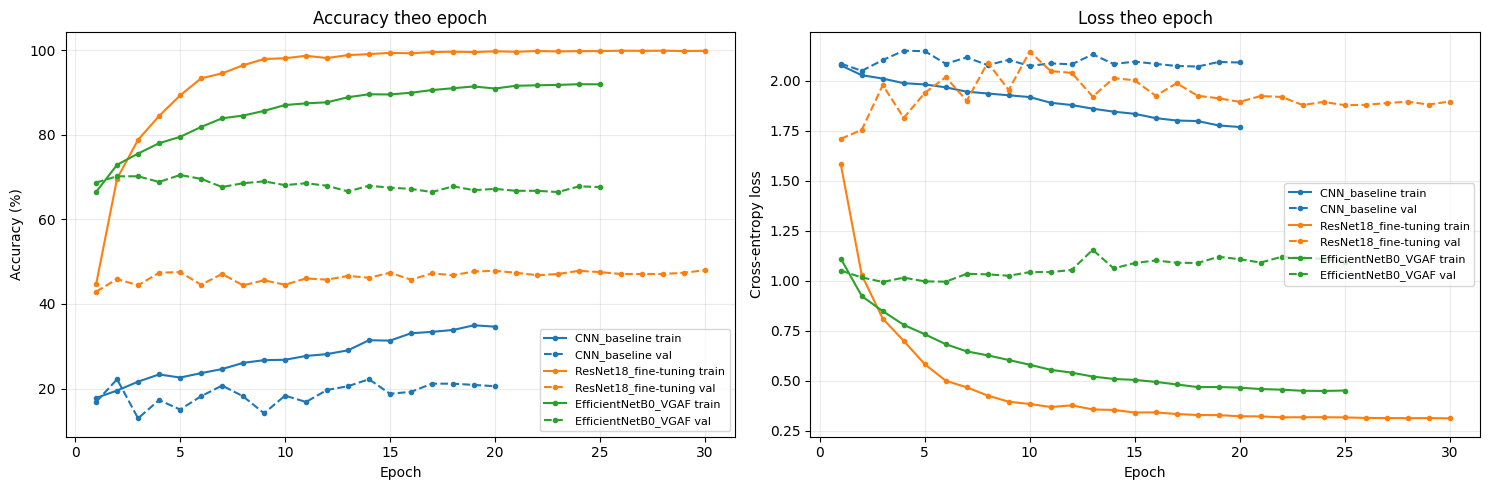

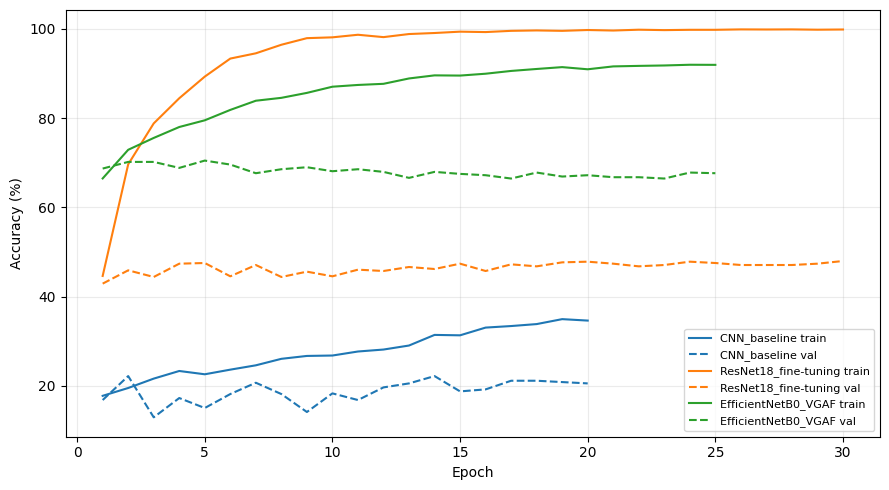

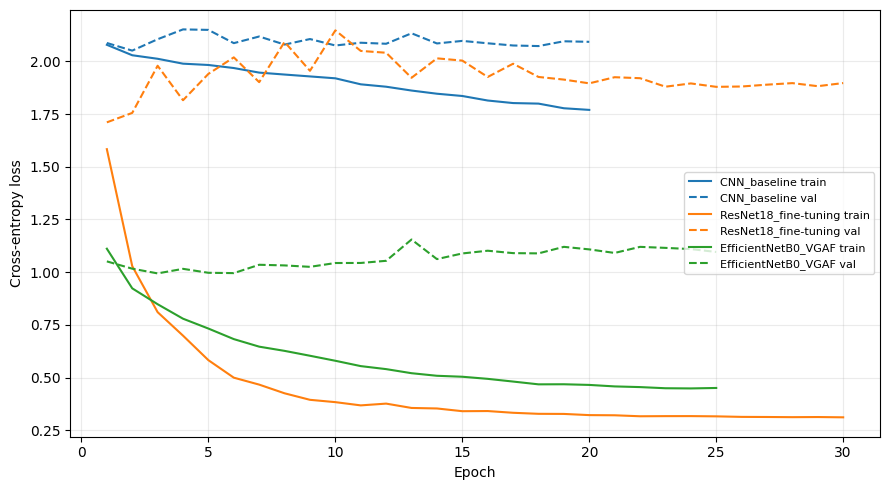

In [13]:
# Em vẽ Accuracy và Loss theo từng epoch để theo dõi quá trình học của các mô hình.
# ResNet18 chỉ fine-tune một giai đoạn nên có một đường train và một đường validation.
plot_history_df = history_df.copy()
model_order = plot_history_df["model"].drop_duplicates().tolist()
color_map = plt.get_cmap("tab10")
model_colors = {name: color_map(i % 10) for i, name in enumerate(model_order)}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model_name, group in plot_history_df.groupby("model", sort=False):
    color = model_colors[model_name]
    axes[0].plot(group["epoch"], group["train_acc"], color=color, linestyle="-", marker="o", ms=3, label=f"{model_name} train")
    axes[0].plot(group["epoch"], group["val_acc"], color=color, linestyle="--", marker="o", ms=3, label=f"{model_name} val")
    axes[1].plot(group["epoch"], group["train_loss"], color=color, linestyle="-", marker="o", ms=3, label=f"{model_name} train")
    axes[1].plot(group["epoch"], group["val_loss"], color=color, linestyle="--", marker="o", ms=3, label=f"{model_name} val")

axes[0].set(title="Accuracy theo epoch", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].set(title="Loss theo epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "accuracy_loss_curves.png", dpi=180, bbox_inches="tight")
plt.show()

# Em lưu riêng từng biểu đồ để thuận tiện đưa vào báo cáo.
for metric, ylabel, filename in [
    ("acc", "Accuracy (%)", "accuracy_curve.png"),
    ("loss", "Cross-entropy loss", "loss_curve.png"),
]:
    plt.figure(figsize=(9, 5))
    for model_name, group in plot_history_df.groupby("model", sort=False):
        color = model_colors[model_name]
        plt.plot(group["epoch"], group[f"train_{metric}"], color=color, linestyle="-", label=f"{model_name} train")
        plt.plot(group["epoch"], group[f"val_{metric}"], color=color, linestyle="--", label=f"{model_name} val")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

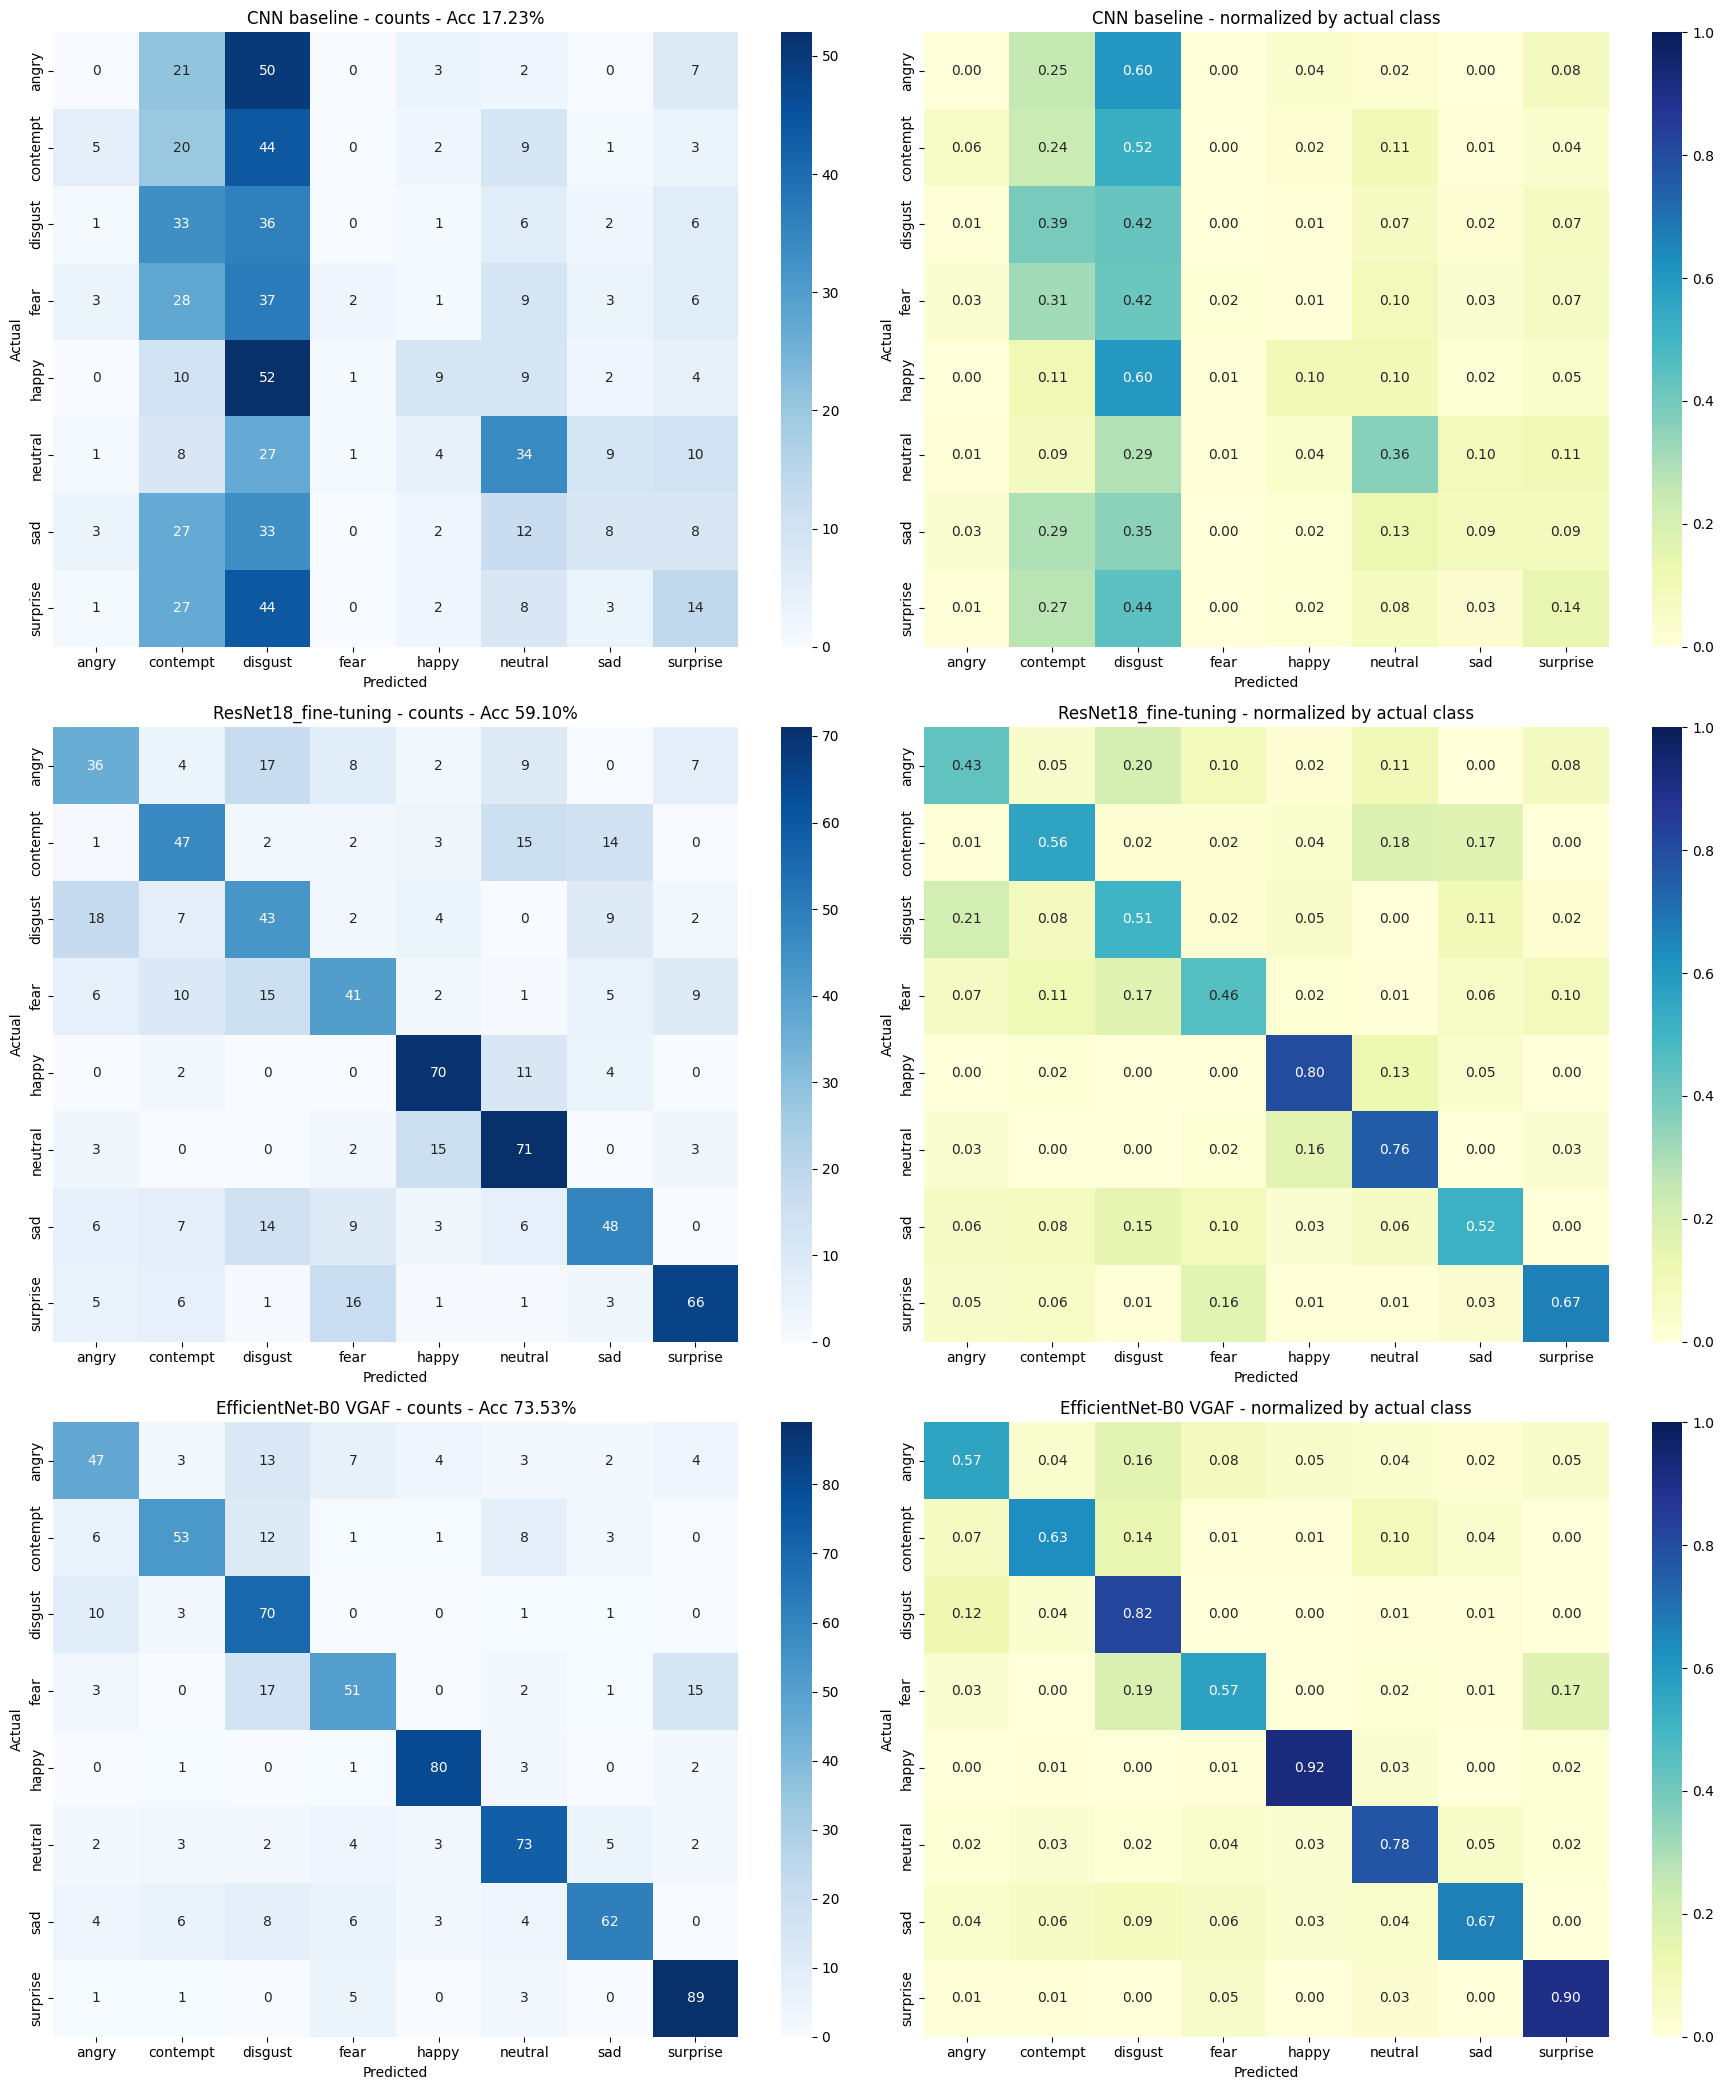

In [14]:
# Em lưu ma trận nhầm lẫn theo số lượng và theo tỉ lệ của từng lớp.
fig, axes = plt.subplots(len(model_evaluations), 2, figsize=(18, 7 * len(model_evaluations)))
for row_index, (model_key, result) in enumerate(model_evaluations.items()):
    cm = confusion_matrix(
        result["y_true"], result["y_pred"], labels=np.arange(NUM_CLASSES)
    )
    cm_normalized = confusion_matrix(
        result["y_true"], result["y_pred"],
        labels=np.arange(NUM_CLASSES), normalize="true",
    )
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        RESULTS_DIR / f"confusion_matrix_{model_key}.csv", encoding="utf-8-sig"
    )
    pd.DataFrame(cm_normalized, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        RESULTS_DIR / f"confusion_matrix_{model_key}_normalized.csv",
        encoding="utf-8-sig",
    )
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[row_index, 0],
    )
    axes[row_index, 0].set(
        title=f"{result['display_name']} - counts - Acc {result['test_acc']:.2f}%",
        xlabel="Predicted", ylabel="Actual",
    )
    sns.heatmap(
        cm_normalized, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[row_index, 1],
    )
    axes[row_index, 1].set(
        title=f"{result['display_name']} - normalized by actual class",
        xlabel="Predicted", ylabel="Actual",
    )

fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrices_all_models.png", dpi=180, bbox_inches="tight")
plt.show()

In [15]:
# Em chỉ giữ các biểu đồ, bảng Accuracy/Loss/F1 và ma trận nhầm lẫn cần cho báo cáo.
allowed_table_names = {"accuracy_loss_f1_summary.csv", "f1_per_class.csv"}
def is_allowed_artifact(path):
    is_confusion_matrix = (
        path.suffix.lower() == ".csv"
        and path.name.startswith("confusion_matrix_")
    )
    return (
        path.suffix.lower() == ".png"
        or path.name in allowed_table_names
        or is_confusion_matrix
    )

# Nếu chạy lại cell, em xóa các tệp phụ cũ để tránh nhầm với kết quả mới.
for artifact in list(RESULTS_DIR.iterdir()):
    if artifact.is_file() and not is_allowed_artifact(artifact):
        artifact.unlink()

# Sau đó, em chép các ảnh và bảng mới nhất về thư mục kết quả chính.
for artifact in sorted(RESULTS_DIR.iterdir()):
    if artifact.is_file() and is_allowed_artifact(artifact):
        shutil.copy2(artifact, RESULTS_ROOT / artifact.name)

print("Đã lưu ảnh, bảng Accuracy/Loss/F1 và ma trận nhầm lẫn tại:", RESULTS_DIR)
for artifact in sorted(RESULTS_DIR.iterdir()):
    print(f"- {artifact.name}: {artifact.stat().st_size:,} bytes")

Đã lưu ảnh, bảng Accuracy/Loss/F1 và ma trận nhầm lẫn tại: D:\developer\computer_vision\Do_An\ket_qua_acc_tren_75\cnn_resnet_emotion\runs\20260624_215400
- accuracy_curve.png: 96,468 bytes
- accuracy_loss_curves.png: 213,823 bytes
- accuracy_loss_f1_summary.csv: 508 bytes
- confusion_matrices_all_models.png: 552,533 bytes
- confusion_matrix_cnn_baseline.csv: 270 bytes
- confusion_matrix_cnn_baseline_normalized.csv: 1,277 bytes
- confusion_matrix_efficientnet_b0_vgaf.csv: 264 bytes
- confusion_matrix_efficientnet_b0_vgaf_normalized.csv: 1,202 bytes
- confusion_matrix_resnet18_fine_tuning.csv: 269 bytes
- confusion_matrix_resnet18_fine_tuning_normalized.csv: 1,234 bytes
- f1_per_class.csv: 585 bytes
- loss_curve.png: 111,153 bytes
